How to create a multi-layer GeoPackage file for the detections
--

In [18]:
from tree_detection_framework.preprocessing.preprocessing import (
    create_dataloader,
)
from tree_detection_framework.detection.detector import GeometricDetector
from tree_detection_framework.detection.region_detections import RegionDetectionsSet

import geopandas as gpd
import fiona 

Step 1: Get the detections using any Detector
----

In [2]:
dataloader = create_dataloader(
    raster_folder_path="/ofo-share/repos/amritha/tree-detection-framework/data/emerald-point-chm/chm.tif",
    chip_size=512,
    chip_stride=400,
    batch_size=3,
    resolution=0.2,
)

detector = GeometricDetector(
    a=0.0045,
    confidence_feature="distance",
    filter_shape="square",
)

predictions = detector.predict(dataloader)

INFO:root:Units = Units.PIXELS
INFO:root:Stride = 400
INFO:root:Using watershed approach to compute the tree crowns.
INFO:root:Using watershed approach to compute the tree crowns.
Performing prediction on batches:   0%|          | 0/6 [00:00<?, ?it/s]

Performing prediction on batches: 100%|██████████| 6/6 [00:14<00:00,  2.35s/it]


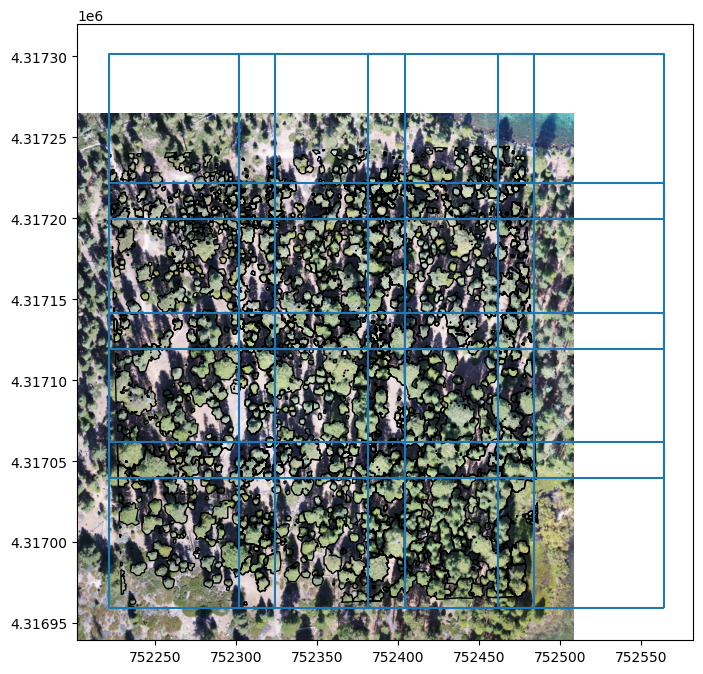

<Axes: >

In [3]:
predictions.plot(
    raster_file="/ofo-share/repos/amritha/tree-detection-framework/data/emerald-point-ortho/ortho.tif"
)

Step 2: Save and (optionally) inspect the RegionDetectionsSet file
---

In [19]:
SAVE_PATH = "/ofo-share/repos/amritha/tree-detection-framework/data/saved-gpkgs/apr-30/detections.gpkg"

# Save the RegionDetectionsSet to a gpkg file with every tile as a separate layer and a 
# layer for the bounds of all tiles called `_bounds`
predictions.save_tiled(SAVE_PATH)

INFO:pyogrio._io:Created 127 records
INFO:pyogrio._io:Created 169 records


INFO:pyogrio._io:Created 98 records
INFO:pyogrio._io:Created 30 records
INFO:pyogrio._io:Created 118 records
INFO:pyogrio._io:Created 181 records
INFO:pyogrio._io:Created 116 records
INFO:pyogrio._io:Created 16 records
INFO:pyogrio._io:Created 221 records
INFO:pyogrio._io:Created 211 records
INFO:pyogrio._io:Created 175 records
INFO:pyogrio._io:Created 29 records
INFO:pyogrio._io:Created 112 records
INFO:pyogrio._io:Created 109 records
INFO:pyogrio._io:Created 126 records
INFO:pyogrio._io:Created 27 records
INFO:pyogrio._io:Created 16 records


Inspect the raw file

In [27]:
# List all layers in the file
fiona.listlayers(SAVE_PATH)

['detections_0',
 'detections_1',
 'detections_2',
 'detections_3',
 'detections_4',
 'detections_5',
 'detections_6',
 'detections_7',
 'detections_8',
 'detections_9',
 'detections_10',
 'detections_11',
 'detections_12',
 'detections_13',
 'detections_14',
 'detections_15',
 '_bounds']

In [ ]:
# Read the saved gpkg file and display detections from tile 0
gpd.read_file(SAVE_PATH, layer="detections_0")

,score,geometry
0,0.0,"POLYGON ((752262.09 4317061.699, 752262.09 431..."
1,0.0,"POLYGON ((752266.29 4317061.699, 752266.89 431..."
2,7.0,"POLYGON ((752262.89 4317061.699, 752264.09 431..."
3,7.0,"POLYGON ((752282.49 4317061.699, 752282.09 431..."
4,0.0,"POLYGON ((752317.69 4317061.699, 752318.89 431..."
...,...,...
122,62.0,"POLYGON ((752294.09 4316972.099, 752293.89 431..."
123,39.0,"POLYGON ((752316.89 4316978.899, 752315.29 431..."
124,37.0,"POLYGON ((752228.69 4316979.299, 752228.89 431..."
125,20.0,"POLYGON ((752235.29 4316965.099, 752234.09 431..."


In [29]:
# Read and display the bounds layer
gpd.read_file(SAVE_PATH, layer="_bounds")

,tile_id,geometry
0,0,"POLYGON ((752323.89 4316959.299, 752323.89 431..."
1,1,"POLYGON ((752403.89 4316959.299, 752403.89 431..."
2,2,"POLYGON ((752483.89 4316959.299, 752483.89 431..."
3,3,"POLYGON ((752563.89 4316959.299, 752563.89 431..."
4,4,"POLYGON ((752323.89 4317039.299, 752323.89 431..."
5,5,"POLYGON ((752403.89 4317039.299, 752403.89 431..."
6,6,"POLYGON ((752483.89 4317039.299, 752483.89 431..."
7,7,"POLYGON ((752563.89 4317039.299, 752563.89 431..."
8,8,"POLYGON ((752323.89 4317119.299, 752323.89 431..."
9,9,"POLYGON ((752403.89 4317119.299, 752403.89 431..."


Step 3: Load the file as a RegionDetectionsSet
---

In [25]:
rds = RegionDetectionsSet.from_tiled_file(SAVE_PATH)

In [26]:
len(rds.region_detections)

16

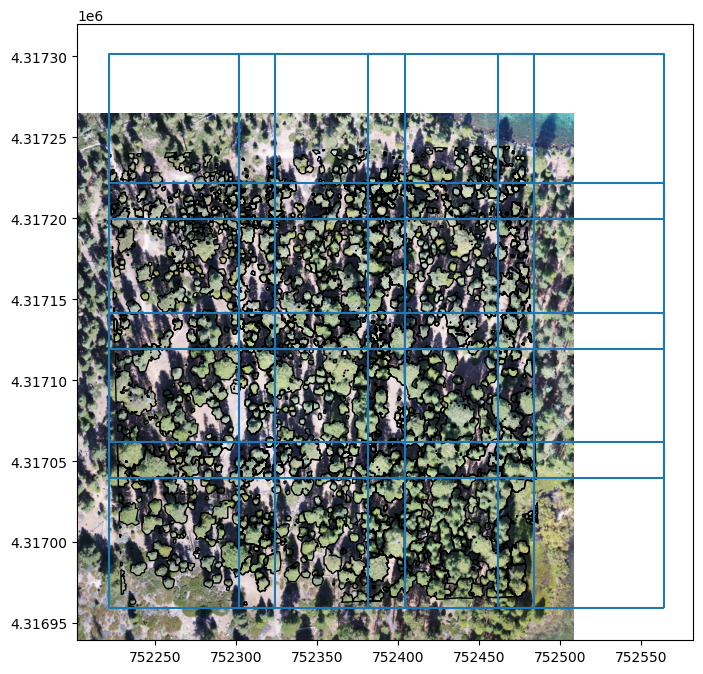

<Axes: >

In [17]:
rds.plot(
    raster_file="/ofo-share/repos/amritha/tree-detection-framework/data/emerald-point-ortho/ortho.tif"
)

The rest of of the postprocessing operations can be performed on this